# Preamble 

This notebook assumes that it is run from docs/tutorials (as a current directory of jupyter lab).

In [1]:
import arviz as az
import numpy as np
import random
import pandas as pd
import scipy.stats as stats
import xarray as xr
from matplotlib import pyplot as plt
from IPython.display import Markdown


# move to a directory to above access the privugger code
import os, sys
sys.path.append(os.path.join("../../"))

In [2]:
# privugger library
import privugger as pv

from IPython.display import display, clear_output

$S$ - the number of students    
$C$ - the number of courses  
$k_i$ - the number of courses the $i$th student is registered in  
$l_j$ - the number of seats in $j$th course  (needs to be somewhat consistent with the above, there should be enough seats for the students)  
$e_{i,j}$ - The $i$th student is enrolled in $j$th course, $i=1..S$, $j=1..C$  
$c_{i,j}$ - the number of comments written by the $i$th student for the $j$th course  
$O$ - the total number of comments (randomized)

A student can only write a comment on the courses they are enrolled in.  
The comments of the student for one course are consecutive, and there is a small chance of interleaving comment block for courses from different students.  
The students work on the course evaluation in an unknown order. Discovering that order, would almost fully re-identify the authors of the comments.

# Synthetic Data Generation

Let's generate a synthetic dataset. 

In [3]:
S = 300  # number of students in the programme
C = 40   # number of courses offered this term

We first generate the number $k$ of courses each student takes,
assuming each student registers in at most 5 courses at a time, 
with mean 3.3, so we take $p = \mu/n$ for the binominal generator. The two constants are based on our 
prior knowledge about the software study programs at the IT University of Copenhagen.

In [4]:
k = np.random.binomial(n = 5, p = 3.3 / 5.0, size = S)
k

array([4, 4, 3, 3, 3, 4, 4, 4, 3, 4, 3, 4, 2, 4, 3, 2, 4, 3, 4, 1, 3, 1,
       4, 4, 3, 4, 4, 2, 1, 3, 3, 5, 3, 4, 3, 1, 5, 4, 4, 5, 2, 5, 3, 4,
       4, 3, 5, 2, 5, 3, 3, 2, 5, 4, 2, 3, 5, 4, 4, 3, 4, 3, 4, 4, 3, 3,
       4, 3, 3, 4, 4, 2, 2, 2, 4, 4, 4, 3, 3, 3, 2, 0, 4, 3, 1, 3, 3, 2,
       2, 3, 4, 3, 3, 3, 2, 4, 3, 4, 2, 5, 2, 4, 5, 2, 4, 3, 3, 3, 3, 3,
       4, 4, 4, 3, 4, 5, 5, 2, 3, 4, 3, 4, 4, 4, 3, 3, 4, 3, 3, 5, 4, 3,
       3, 4, 4, 5, 4, 4, 4, 1, 2, 4, 3, 5, 4, 3, 5, 5, 3, 2, 4, 3, 3, 3,
       3, 5, 5, 4, 2, 4, 4, 3, 4, 1, 5, 1, 4, 2, 4, 4, 2, 3, 4, 4, 3, 4,
       3, 1, 4, 5, 5, 4, 2, 4, 4, 3, 3, 4, 3, 3, 3, 3, 2, 3, 3, 2, 3, 3,
       3, 4, 2, 3, 3, 3, 3, 4, 5, 4, 2, 1, 3, 5, 3, 3, 0, 3, 4, 5, 2, 4,
       1, 4, 4, 4, 4, 3, 2, 4, 4, 2, 3, 3, 5, 2, 4, 1, 4, 4, 4, 2, 4, 3,
       4, 4, 3, 4, 4, 5, 5, 2, 4, 3, 4, 4, 4, 3, 5, 3, 4, 3, 3, 5, 4, 2,
       3, 5, 5, 2, 3, 4, 2, 3, 3, 0, 4, 3, 3, 4, 2, 4, 4, 4, 3, 3, 3, 2,
       4, 2, 5, 3, 4, 3, 4, 2, 5, 2, 2, 2, 4, 4])

Now  generate the number of seats in each course, as we want to 
have both large and small courses.  A typical course takes 30 students (the number of seats is larger, but not all are taken).
It turns out that a Poisson distribution has too low variance for modeling the course size distribution at IT University.  
The smallest courses I get from Poisson are about 14 students, and the largest are ca. 34.  The spread of course sizes at ITU is much larger.  Thus I tried with negative binomial, and shift the sample right by 15, to ensure that each course has at least 15 seats. I think about 15 is a minimum seat assignment at ITU typically.  Unlike Poisson, negative binomial allows choosing a different mean and standard deviation.


In [5]:
μ_size = 30
σ_size = 50
r_size = μ_size * μ_size / (σ_size * σ_size - μ_size)
p_size = μ_size /(σ_size * σ_size)
# sample C courses, then fix everything by 4, so that the smallest courses have 4 students`
l = np.random.negative_binomial(n = r_size, p = p_size, size = C)
l = l + 15
l

array([ 17,  21,  34,  75,  16,  16, 125,  15,  56,  16,  21,  41,  48,
        25,  18, 130, 101,  15,  44,  16,  67,  15,  36,  20,  23,  15,
        15, 113,  15,  15,  22,  38,  70,  19,  16,  57, 107,  30,  15,
        15])

Let's plot the distribution of course sizes (defined as number of seats offered).

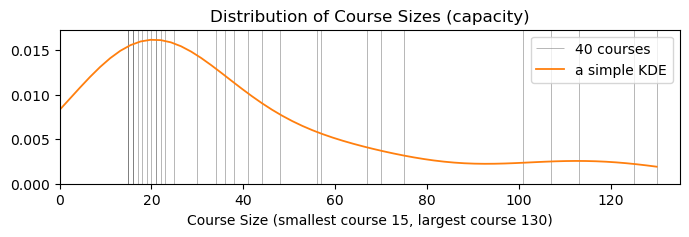

In [6]:
l_sorted = np.sort(l)
_ ,ax = plt.subplots (1, figsize = (8, 2))
ax.vlines(x = l_sorted, ymin = 0, ymax = 2, colors = 'gray', lw = .4, label = f"{len(l)} courses")

xs = np.linspace(0, l_sorted[-1], 60)
kde = stats.gaussian_kde(l_sorted).evaluate(xs)
ax.plot(xs, kde, color = 'C1', lw = 1.3, label = f"a simple KDE")

ax.set_title("Distribution of Course Sizes (capacity)")
ax.set_xlim(0, l.max()+5)
ax.set_ylim(0, kde.max()*1.07)
ax.set_xlabel(f"Course Size (smallest course {l.min()}, largest course {l.max()})")
ax.legend();

Check that there are enough seats for all students in the courses


In [7]:
k_sum = k.sum() # the total number of registrations to execute
l_sum = l.sum() # the total number of course seats available
assert l_sum >= k_sum, f"There is only {l_sum} seats int the courses but students ask for {k_sum}"

Populate courses with students. We assign the students with more unassigned courses first, and the larger courses first. More precisely, we give these a probabilistic upper hand.

In [8]:
e = np.zeros((S, C), dtype=int)
while k_sum > 0:
    p_enrollments = k / k_sum # prob. distribution of picking up a student
    p_seats = l / l_sum       # prob. distribution of picking up a course
    i = np.random.choice(S, p = p_enrollments)
    k[i] -= 1
    k_sum -= 1
    j = np.random.choice(C, p = p_seats)
    l[j] -= 1
    l_sum -= 1
    e[i,j] = 1
e

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 1, 0]])

(NB. `e[i][j] = 1` is the $i$th student being enrolled in the $j$th course).

Cancel courses below three students

In [9]:
MIN_COURSE = 3
column_sums = np.sum(np.array(e), axis=0)
e = e[:, column_sums >= MIN_COURSE]

r_sorted = np.sort(np.array([np.sum(e[:,course]) for course in range(C)]))
assert len(r_sorted) == len(r_sorted[r_sorted >= MIN_COURSE])

display (Markdown (f"I cancelled {C-len(r_sorted)} courses."))
r_sorted

I cancelled 0 courses.

array([ 5,  7,  9,  9,  9,  9, 10, 10, 10, 10, 10, 11, 11, 11, 11, 11, 12,
       13, 14, 14, 16, 16, 17, 18, 20, 21, 24, 25, 26, 31, 31, 33, 41, 41,
       48, 52, 61, 68, 71, 72])

In [10]:
# a quick sanity test
assert r_sorted.sum() == e.sum()

Plot of the actual registrations (the actual course sizes after the registration process).

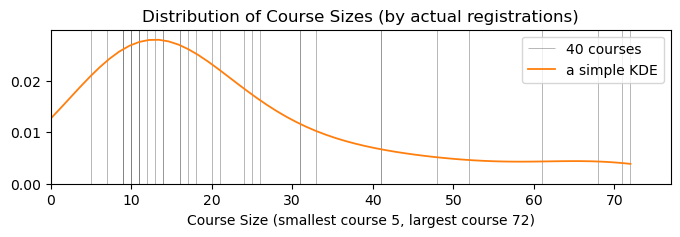

In [11]:
_ ,ax = plt.subplots (1, figsize = (8, 2))
ax.vlines(x = r_sorted, ymin = 0, ymax = 2, colors = 'gray', lw = .4, label = f"{len(r_sorted)} courses")

r_xs = np.linspace(0, r_sorted[-1], 60)
r_kde = stats.gaussian_kde(r_sorted).evaluate(r_xs)
ax.plot(r_xs, r_kde, color = 'C1', lw = 1.3, label = f"a simple KDE")

ax.set_title("Distribution of Course Sizes (by actual registrations)")
ax.set_xlim(0, r_sorted.max()+5)
ax.set_ylim(0, r_kde.max()*1.07)
ax.set_xlabel(f"Course Size (smallest course {r_sorted.min()}, largest course {r_sorted.max()})")
ax.legend();

And as a sanity check plot also the number of registrations per students (so how many courses students take).

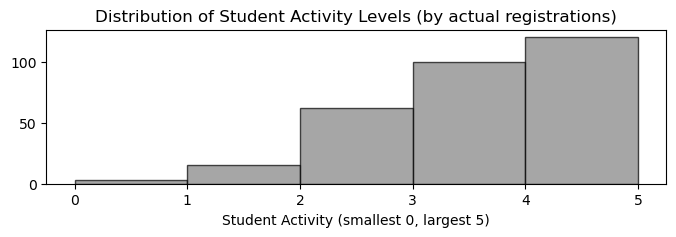

In [12]:
s_sorted = np.sort([np.sum(e[student,:]) for student in range(S)])
_ ,ax = plt.subplots (1, figsize = (8, 2))
_, bins,_ = ax.hist(s_sorted, bins=s_sorted.max(), color='gray', edgecolor='black', alpha=0.7)
ax.set_xticks (bins.astype(int))
ax.set_title("Distribution of Student Activity Levels (by actual registrations)")
ax.set_xlabel(f"Student Activity (smallest {s_sorted.min()}, largest {s_sorted.max()})");
#ax.legend();

In [13]:
# sanity check
# the largest course (r_sorted[-1]) has less students than the number of seats assigned to the largest course (l_sorted[-1])
assert l_sorted[-1] >= r_sorted[-1]

Reduce the number of courses to those that are actually running (some might have received no registrations)

In [14]:
C = len(r_sorted)
C

40

We first generate the student comments for the courses they are enrolled in.
Assume that a typical student writes two comments per course.  We are not yet ordering these comments in any way. Note that for simplicity this creates comments also for courses where the students are not registered. We filter them out then.

In [15]:
c = np.random.poisson(lam = 2, size=(S, C))
skipped = 0
# remove comments for courses where the students are not registered
for student in range(S):
    for course in range(C):
        if e[student][course] == 0:
            c[student][course] = 0
        if e[student][course] == 1 and c[student][course] == 0:
            skipped += 1
            
total_comments = c.sum()
total_comments

1895

In [16]:
skipped

132

We shall now schedule writing the above comments in time.  Assume that there are $H$ hours for performing the evaluation. For simplicity, a student performs evaluation within an hour. Then $H = 250$ amounts to about 10 days (by decreasing this number we introduce more noise, as more students will write evaluations at the same time, and their indices will be conflated.

In [17]:
H = 250 

Randomly assign the writing hour for each student (`h[t]` is the time when student evaluates).

In [18]:
h = np.random.choice(range(H), size=S)
h

array([ 48, 170, 235,  67, 204,  98, 138,  86, 211, 103,  12, 126, 209,
       136, 195,  16,  81,  56, 140,  36,  99, 190,  22,   9, 192, 188,
        12, 172,  29,  85, 109, 191,  84,  90, 184, 132,  66,  28,  65,
       135, 229,  42, 171, 171, 131, 111, 119, 205, 145,  99, 147, 212,
       144, 229, 159,  42, 158, 207, 245,  69,  33, 106,  51,  41, 182,
        55, 208, 246,  80,  13, 204, 158, 126, 193,  41,  75,  42,   4,
       212,  12, 177,  50,  19, 159,  59, 178, 133,  45,   1, 118, 205,
        68, 197,  98, 158,  43, 102, 219, 121, 240, 176, 204,  87,  88,
       177,  19, 197, 241, 137, 135,  22,  70,  90,  55,  32, 189, 230,
       163, 141,  54, 168, 160,   9, 102, 235,  18, 122, 135,   8,  20,
        80,  63,   5,  73, 101,  59, 190, 169,  10, 194,  64, 242, 178,
       208, 108,  69,  80, 145,  73, 180, 130,  33,  96,  68,  85, 158,
        46, 167,   0, 210,  38, 244, 138,  44,  38,  56, 118, 164, 239,
       130, 176,  65, 223,  35,  35, 184, 161,  29,  48,  12, 18

We are going to store the evaluation log visible in the online system in the `output` variable as quadruples: time, student, course, and a comment id. The loop below produces the output, for all the time intervals, shuffling the students randomly.  Note that comments for a single course are not mixed between students (they receive consecutive ids).  Comments for different courses may interleave between students (actually a more leaking implementation would not mix courses, and we can also try that).

In [19]:
output = []
available_comment_id = 0

for t in range(H):
    # students allocated to the current hour (the first component is the actual array)
    active_students = np.where(h == t)[0]
    # narrow down to students that have not written all their comments yet
    active_students = [ student_id for student_id in active_students if c[student_id,:].sum() > 0 ]
    
    while active_students:
        student_id = random.choice(active_students)
        # write comments in the order of courses (we take them in the order of increasing course ids)
        # argmax will return the index of the first True (if there is a tie among several)
        course_id = np.argmax(c[student_id, :] > 0)
        evaluations = [ (t, student_id, course_id, available_comment_id + comment_id) 
                        for comment_id 
                        in range(c[student_id, course_id]) ]
        assert e[student_id, course_id] == 1, "student commenting on a course they are not registered for!"
        output.extend(evaluations)
        available_comment_id += c[student_id, course_id]
        c[student_id, course_id] = 0
        if c[student_id, :].sum() == 0:
            active_students.remove(student_id)
        print (f"{student_id}@{course_id} ", end='')

158@32 211@14 211@22 211@27 88@22 88@36 77@2 77@16 77@22 132@16 132@36 128@6 128@27 23@4 23@16 23@26 23@36 122@20 122@27 122@32 122@36 138@7 138@15 138@21 138@30 197@6 26@3 79@12 10@2 79@32 79@35 26@6 10@16 10@28 179@10 179@16 179@27 26@20 179@35 26@32 69@15 69@32 69@35 201@2 201@6 201@8 202@4 192@6 202@10 202@16 15@27 216@14 216@15 216@27 258@3 216@38 258@23 258@26 289@15 289@27 289@32 125@13 125@16 125@24 82@3 249@5 249@39 82@15 105@18 105@32 82@39 275@3 225@3 129@4 275@6 225@15 225@35 129@5 129@16 129@25 129@34 291@6 291@20 291@36 110@15 110@26 234@2 234@12 22@1 234@15 22@3 22@18 206@15 186@8 206@16 186@16 206@28 206@35 206@36 37@6 37@27 274@2 274@27 177@23 200@15 28@13 200@36 188@32 257@3 257@4 257@14 261@12 261@13 261@36 261@37 198@32 114@8 114@22 114@36 60@11 60@15 250@3 290@12 250@4 250@27 151@15 250@32 60@20 60@27 290@16 290@18 151@22 151@35 173@11 174@4 174@35 173@14 173@25 248@3 19@5 248@6 248@11 270@14 270@27 164@10 164@13 164@15 160@6 164@30 160@8 160@20 160@32 63@15 74@32 

An evaluation is a tuple: time, student, course, comment_id

In [20]:
output_df = pd.DataFrame(output, columns = ['t', 'student', 'course', 'comment'])
output_df

,t,student,course,comment
0,0,158,32,0
1,0,158,32,1
2,0,211,14,2
3,0,211,14,3
4,0,211,22,4
...,...,...,...,...
1890,249,222,34,1890
1891,249,222,34,1891
1892,249,222,34,1892
1893,249,222,34,1893


In [21]:
output_df['position'] = range(len(output_df))
output_df.set_index(["position"], inplace = True)
output = xr.Dataset.from_dataframe(output_df)

In [22]:
output

<xarray.Dataset>
Dimensions:   (position: 1895)
Coordinates:
  * position  (position) int64 0 1 2 3 4 5 6 ... 1889 1890 1891 1892 1893 1894
Data variables:
    t         (position) int64 0 0 0 0 0 0 1 1 ... 249 249 249 249 249 249 249
    student   (position) int64 158 158 211 211 211 211 ... 222 222 222 222 222
    course    (position) int64 32 32 14 14 22 27 22 22 ... 30 30 34 34 34 34 35
    comment   (position) int64 0 1 2 3 4 5 6 ... 1889 1890 1891 1892 1893 1894

The entire generated data sets consist of the following:
* The `output` variable that links students, course, and comment_id
* The `e` array tracking which student is registered for what courses

Let's do a test: each student commenting on a course is enrolled in the course.

In [23]:
for i in output.position.values:
    assert e[output.student.values[i], output.course.values[i]] == 1

# Leakage Modeling

* We have now generated the data. What we want to do is to release the comment column.
* The attacker has access to student enrolement (the $e_{ij}$ array). 
* We want to measure leakage of information to the non-existing (explicitly) variable comment-author $a_{ik}$ that matches the student $i$ to a comment $k$. We want to find maximum leakage of this kind (find some individuals), ideally given an existing data set
* The PyMC model should have the data generated by the above process ($e_{ij}$) and the time series of comments and course ids $\{i,j\}$.
* Let's start with prototyping the disclosure program to make things more concrete:

In [24]:
# dataset: time x student x course x comment, e: student x course 
# returns: student x course, comment x course
# Q. Why is the program so complex if it only drops 'time x student' (or perhaps just the student)
def release(dataset, e):
    
    student_course = []
    for student_index in range(e.shape[0]):
        for course_index in range(e.shape[1]):
            if e[student_index, course_index] == 1:
                student_course.append((student_index, course_index))

    student_course     = np.array(student_course) 
    sorted_student_ids = np.argsort(student_course[:, 0])
    student_course     = student_course[sorted_student_ids]

    comment_course     = np.array(list(zip(dataset.comment.values, dataset.course.values)))

    return student_course, comment_course

# The attacker wants to learn is: comment x student; I want Pr (comment = x, student = y) 
# Prior: time x student x course x comment but not e: student x course 
# students_of_j: e[*,j]
# comment_course [ _, _, j, _ ] for j uniform prior (students_of_j), (droppable: and zero otherwise)
# and I need to do this for all students
# the number of random variables is |dataset|
# but this is still too weak, we need to model the temporal dependencies (via likelihood/observations?)
# this will not scale; add to prior that if a student changes in dataset, then he cannot come back ever again.  Can we do that?

In [25]:
student_course, comment_course = release(output,e)

In [26]:
comment_course

array([[   0,   32],
       [   1,   32],
       [   2,   14],
       ...,
       [1892,   34],
       [1893,   34],
       [1894,   35]])

In [27]:
student_course

array([[  0,   7],
       [  0,  15],
       [  0,  20],
       ...,
       [299,  32],
       [299,  15],
       [299,  38]])

* In general: The attacker wants to learn is: comment -> student (or student -> comment)
* Can I learn a P(comment * student)? And then find the lowest entropy, lowest variance, highest probability points?
* In such case the secret 'dataset' has to be replaced with attackers prior, but we want to use the concrete output (so this is very much like ESORICS)
  * The prior should be derived from e_ij (it should be uniform between the comments of $e_{i\ast}$ courses)
* Given the actual data-set, I probably cannot asses leakage? Can I? But I can only assess uncertainty on a particular comment, say a journalist attack (has this student written this comment)?  but will this scale? Don't we need SAT-MC to do this?
* What is the likelihood function I need to evaluate?

## Understanding the dimensionality of the problem

What's the minimal number of student-comment variables we need? The attacker knows in which courses the student is registered.

**TODO:** students are registered for too many courses! We need a plot with a student - course count distribution above. (This is now plotted and it seems fine) Fix the bug, then the code below should be able to get dimensionality.

In [28]:
# Group by course_id using a dictionary
comments_per_course = {}
for _, course_id in comment_course:
    comments_per_course[course_id] = grouped.get(course_id, 0) + 1

NameError: name 'grouped' is not defined

In [ ]:
# Convert to a simpler array
stud_comment_count = sum([ comments_per_course[course] for student, course in student_course])
display (Markdown(f"We need **{stud_comment_count}** variables to model the association between the students and comments, if we exploit the registration data in the model structure."))

**TODO**: A sanity check is to calculate the same thing from looking at how many students each course has. It should give the same number?

# Privugger

* Start with a naive attacker, some uniform weak priors\n",
* Make a Boolean array students $\\times$ comments (the $e$ array serves as a likelihood perhaps). This could allow to build a model without the timining information. But then how can we reason about leakage in this model? As a baseline for another model?\n",       ....
* Causal secondary information: consecutive ids.
* We could also have a prior with 0.5 in the comments array (we could infer the probability that the student has written a comment, and compare it with the ground truth).
* Consider how we can anonymize it somehow (DP or so)
* 250114
    * Can we analyze for one student at a time? We did this in the netflix example.    * What's the minimal number of student-comment variables we need? (by looking at the registrations and counting)
    * Can we analyze for one student at a time? We did this in the netflix example. AW believes that this should give an underestimation of leakage, becase we have a global napsack problem, so maximizing likelihood for all student-comment links decreases chance for some local optima (it is like a table 

In [ ]:
student_no = max(student_course [:,0])+1
course_no = max(student_course[:,1])
comment_no = max(comment_course[:,0])

We want to model a relation: Distrib(P(student_id x comment_id)), but it should be easier Dist(student_id x comment_id), or even student_id x Dist(Boolean)^comment_id

Assume that the number of students, course, and comment_no (get them from the observation and make constants in prior)

In [ ]:
c2s = pv.Uniform("c2s", lower=0.0, upper=1.0, num_elements= (comment_no, student_no))

The above seems extensional. As now we really have a 3D space ... I think there was a way to make it simpler, where observations where coming from the comments arrays only

### Modeling Notes (salvaged from a merge conflict on 2025-02-14)
* One way to do this: model everything with priors, compose with $e_ij$, this reduces uncertainty. So to simplify things $e_ij$ goes into the prior.
* How can the result of the analysis be used with the existing data set? We can also check the prediction error? A new kind of leakage maesure?
* We could difference from mode solution, or compare the mode posterior probability and the actual dataset probability; possibly also zoomed at the individual students, to see who is most vulnerable.
